In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

In [2]:
# 신경망 구성에 필요한 라이브러리 임포트
import torch
from torch import nn            # nn 모듈
from torch.optim import Adam    # 최적화 (Adam 많이 씀)
# 파이토치에서 데이터를 다룰 때 사용하는 도구들
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# 디바이스 준비 (GPU, CUP)
# 파이토치 설치 : GPU 버전으로 설치 -> GPU도 사용할 수 있고, CPU도 사용할 수 있다.
# CPU버전으로 설치하면 CPU만 사용하게 된다.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# 데이터 전처리 1  (텐서 변환 전)

# 데이터 불러오기
path = 'https://bit.ly/advertising_csv'
adv = pd.read_csv(path)


# x, y 분할
target = 'Sales'
x = adv.drop(target, axis=1)
y = adv.loc[:, target]


# 학습/검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=20)
print(type(x_train), type(x_val))


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
print(type(x_train), type(x_val))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [5]:
# 데이터 전처리 2  (텐서 변환 하기)

# 텐서 변환

x_train_ts = torch.tensor(x_train, dtype=torch.float32)
# 📢 y_train_ts는 Series이다 => 텐서 변환이 안됨 y_train.values (ndarrary) => tensor 변환
# 📢 y_train.values (ndarray) => tensor 변환 => 1차원이다. => 신경망에 들어 갈 때 2차원이어야 한다.
# 그래서 1차원 2차원으로 변환이 필요하다 : .view(-1, 1) => torch의 tensor 오브젝트 메소드, 2차원 변환

y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_val_ts = torch.tensor(x_val, dtype=torch.float32)
y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)


# to(이동할 장치 지정) 메소드 : 데이터 이동 => ⭐"텐서"만 가능
# 디바이스 할당 (전처리의 RAM에 있는것을 GPU(VRAM)로 옮기기)
x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)

# 반대로 device : cpu => GPU => CPU 이동
# device='cpu'
# x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
# x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)


In [6]:
# 1. 학습에 사용할 텐서 데이터셋 생성

# 1.1 배치 사이즈 : 전체 데이터에서 한번 학습에 사용할 데이터 크기 지정
BATCH_SIZE = 32     # 32개씩 모델에 들어가겠다는 뜻, 대문자 표기 => 상수 의미

# 1.2 텐서 데이터셋 생성 => 데이터 준비 완료
train_ds = TensorDataset(x_train_ts, y_train_ts)

# 2. 데이터 로더 구성 : 데이터(train_ds)를 모델에 넣어주는 놈이다.
# 한번 학습에 32개씩 데이터 넣겠다란 의미
train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True    # shuffle=True : 섞어서 학습
)

In [7]:
## 데이터 준비 완료

# 데이터 전처리 1
# => 데이터 전처리 2 => 텐서 변환, GPU 이동
# => 학습에 사용할 데이터 집합 생성 : TensorDataset (텐서 데이터셋)
# => 모델에 데이터를 넣어 주는 놈 생성 : DataLoader (데이터 로더)

In [8]:
## 신경망 모델 생성

# 1. 모델 구조 생성 : 3가지 방법이 있다. => 가장 쉬운 방법 (정밀하지 못하다)

# 모델(신경망) 구조 (시퀀스 이용 방법)

# 1.1 신경망 : Shape[1] => 입력 행렬의 열의 크기 => 신경망의 행의 크기가 되어야 한다. => 입력층의 노드 수
in_features = x_train_ts.shape[1]


# 1.2 신경망 생성하고 GPU로 이동
model = nn.Sequential(      
    nn.Linear(in_features, 1)
    ).to(device)

In [9]:
# 학습 방법을 지정 : 손실함수, 옵티마이저 구성
loss_fn = nn.MSELoss()    # 손실함수 : 평균제곱오차

# model.parameters() : 가중치(W) 추출 최적화 : Adam,  lr : 학습률
optimizer = Adam(model.parameters(), lr=0.01) 

In [ ]:
# 학습 진행
EPOCHS = 100    # 에포크 : 반복횟수 (100번)
tr_loss_list, val_loss_list = [], []


# 1. 학습 데이터 반복 학습
for epoch in range(EPOCHS):     # 100번 반복
    model.train() # 모델 학습 모드, eval() 평가 모드 변경
    total_loss = 0.0    # 전체 오차    
    n_batch = 0         # 배치 갯수


    # 2. 에포크마다 배치 단위 학습
    for x, y in train_loader:   # 데이터를 모델에 넣어주는 놈 (배치 사이즈 만큼씩)
        x, y = x.to(device), y.to(device)


        # 3. 학습
        # 순전파(Feed Forward Learning) : 학습 데이터에서 오차 계산
        pred = model(x) # 모델에 x를 입력해 예측



## 여기부터가 진짜 학습

        # 오차 역전파(Backward Learnig) : 오차로부터 가중치 업데이트
        loss = loss_fn(pred, y) # 오차 계산 : pred(모델을 통과해서 나온 값 : 1개, 예측값) - y (원래답)
        optimizer.zero_grad() # 기울기(gradient) 초기화 (0으로 만듬)
        loss.backward() # 손실 함수를 기준으로 각 가중치의 기울기를 계산
        optimizer.step() # 기울기를 기준으로 가중치 조정  => 역전파 학습


        total_loss += loss.item()
        n_batch += 1


    # 에포크마다 학습 오차 집계
    tr_loss = total_loss / n_batch


    # 4. 검증
    model.eval() # 모델 평가/추론 모드 변경
    with torch.no_grad():   # 학습하지 마라
        val_pred = model(x_val_ts)  # 예측값 추출
        val_loss = loss_fn(val_pred, y_val_ts)  # 오차 구해야 한다.

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss.item())

    # train loss : 학습 데이터에 대한 오차, val loss : 테스트 데이터에 대한 오차
    print(f'Epoch {epoch+1 : 4d} | train loss {tr_loss:.4f} | val loss {val_loss:.4f}')

Epoch    1 | train loss 207.1570 | val loss 215.7689
Epoch    2 | train loss 203.9294 | val loss 212.5879
Epoch    3 | train loss 200.7881 | val loss 209.4106
Epoch    4 | train loss 197.7029 | val loss 206.2464
Epoch    5 | train loss 194.5510 | val loss 203.1294
Epoch    6 | train loss 191.5170 | val loss 200.0326
Epoch    7 | train loss 188.4471 | val loss 196.9804
Epoch    8 | train loss 185.4412 | val loss 193.9626
Epoch    9 | train loss 182.5587 | val loss 190.9505
Epoch   10 | train loss 179.5362 | val loss 188.0103
Epoch   11 | train loss 176.6216 | val loss 185.1105
Epoch   12 | train loss 173.7800 | val loss 182.2378
Epoch   13 | train loss 170.9660 | val loss 179.3938
Epoch   14 | train loss 168.1775 | val loss 176.5851
Epoch   15 | train loss 165.4049 | val loss 173.8195
Epoch   16 | train loss 162.7270 | val loss 171.0718
Epoch   17 | train loss 159.9980 | val loss 168.3796
Epoch   18 | train loss 157.3435 | val loss 165.7242
Epoch   19 | train loss 154.7486 | val loss 16

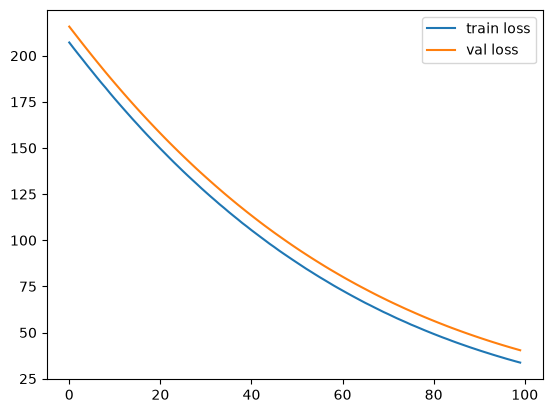

In [11]:
# 시각화

plt.plot(tr_loss_list, label='train loss')
plt.plot(val_loss_list, label='val loss')
plt.legend()
plt.show()